<a href="https://colab.research.google.com/github/TechPius/AI-ENGINEERING-WITH-GOMYCODE/blob/main/Copy_of_GOMYCODE_UNSUPERVISED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLUSTERING ALGORITHMS

- Heirachical
- Partitional

Using [Customers dataset](https://docs.google.com/spreadsheets/d/e/2PACX-1vTaFo7KAmS2yxX_fV_F6DxSgyVe2-fvpmxL5vlXAhxgiF2hkPn2w2XjHpDjqLAe--nAxJgQo92jbd2l/pub?gid=451627532&single=true&output=csv)

## Data Preprocessing

In [ ]:
import numpy as np
import pandas as pd
data=pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTaFo7KAmS2yxX_fV_F6DxSgyVe2-fvpmxL5vlXAhxgiF2hkPn2w2XjHpDjqLAe--nAxJgQo92jbd2l/pub?gid=451627532&single=true&output=csv")

data.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


Preprocessing
- drop unnecessary column
- convert categorical to numerical

In [ ]:
newdata=data.drop("CustomerID", axis=1)
newdata["Gender"]=data["Gender"].map({"Male":1, "Female":0})  #convert Gender values into numerical
newdata.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
5,0,22,17,76
6,0,35,18,6
7,0,23,18,94
8,1,64,19,3
9,0,30,19,72


In [ ]:
newdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [ ]:
#create copies of customer data for clustering

heir_customers = newdata.copy()
Kmeans_customers = newdata.copy()

## Heirachical

To find Optimal Number of clusters:

- generate linkage matrix
- plot a dendrogram

### Create linkage matrix

In [ ]:
#Import heirachical clustering model to create linkages
import scipy.cluster.hierarchy as shc

Check clustering reliability

 Use  cophenet() function to find [Cophenetic Correlation Coefficient](https://en.wikipedia.org/wiki/Cophenetic_correlation) of your clustering. It compares (correlates) the actual pairwise distances of all your samples to those implied by the hierarchical clustering. The closer the value is to 1, the better the clustering preserves the original distances.

In [ ]:
# use cophenet function to check
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

In [ ]:
linkage_methods=['single', 'complete', 'average','centroid','weighted', 'median', 'ward']
coph_list =[]
for linkage_method in linkage_methods:
  test_clusters = shc.linkage(heir_customers, method=linkage_method, metric='euclidean')
  c, coph_dists = cophenet(test_clusters, pdist(heir_customers))
  coph_list.append(c)
  print(f"Cophenet coefficient is {c} for {linkage_method.capitalize()} linkage.")
max_coph = np.max(coph_list)
best_link_method = linkage_methods[coph_list.index(max_coph)]
print(f"\nHighest Cophenet coefficient is {max_coph} for {best_link_method.capitalize()} linkage.")

Cophenet coefficient is 0.6447864656541485 for Single linkage.
Cophenet coefficient is 0.6280559929759395 for Complete linkage.
Cophenet coefficient is 0.6885217002750316 for Average linkage.
Cophenet coefficient is 0.683372670187016 for Centroid linkage.
Cophenet coefficient is 0.635377469503678 for Weighted linkage.
Cophenet coefficient is 0.6404433241596214 for Median linkage.
Cophenet coefficient is 0.66837812145403 for Ward linkage.

Highest Cophenet coefficient is 0.6885217002750316 for Average linkage.


In [ ]:
coph_list

[0.6447864656541485,
 0.6280559929759395,
 0.6885217002750316,
 0.683372670187016,
 0.635377469503678,
 0.6404433241596214,
 0.66837812145403]

In [ ]:
a = np.max(coph_list)
a

0.6885217002750316

In [ ]:
b = coph_list.index(a)
b

2

In [ ]:
linkage_methods[b]

'average'

In [ ]:
clusters = shc.linkage(heir_customers, method=best_link_method, metric='euclidean')
clusters.shape

(199, 4)

### Plot dendrogram

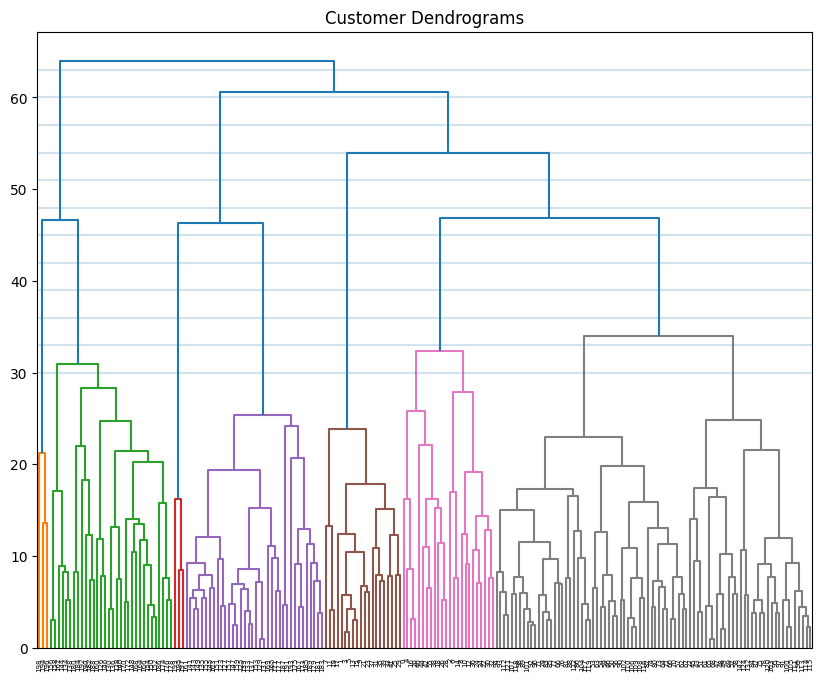

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
plt.title("Customer Dendrograms")
shc.dendrogram(clusters, no_plot=False)  #pass the linkage matrix into dendrogram function
for i in range(30,65, 3):
  plt.axhline(y=i, alpha=0.2, label = str(i))
plt.show()

Choice of optimal no of clusters is betweem 4 and 7.

In [ ]:
no_clusters = 7

### Implement clustering
Import clustering tool to implement agglomerative clustering.

In [ ]:
# Importing our clustering algorithm : Agglomerative

from sklearn.cluster import AgglomerativeClustering
# initiate model
ag_model = AgglomerativeClustering(n_clusters=no_clusters, affinity='euclidean', linkage=best_link_method)
ag_model

AgglomerativeClustering(affinity='euclidean', linkage='average', n_clusters=7)

In [ ]:
#Applying agglomerative algorithm with 7 clusters, using euclidean distance as a metric
clust_labels = ag_model.fit_predict(heir_customers)

clust_labels

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


array([1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 2, 4, 2, 4, 2, 4,
       0, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 5, 6, 5, 6,
       5, 6])

add clusterlabels to dataframe

In [ ]:
heir_customers['cluster'] = ag_model.labels_
heir_customers.sample(15)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
134,1,20,73,5,2
65,1,18,48,59,0
86,0,55,57,58,0
59,1,53,46,46,0
76,0,45,54,53,0
140,0,57,75,5,2
170,1,40,87,13,2
48,0,29,40,42,0
183,0,29,98,88,4
21,1,25,24,73,3


In [ ]:
heir_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
 4   cluster                 200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


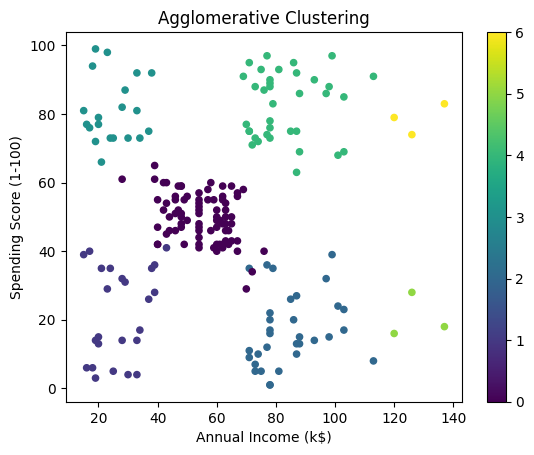

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure()
ax = fig.add_subplot(111)

# Use a colormap for the scatter plot
scatter = ax.scatter(heir_customers['Annual Income (k$)'],
                     heir_customers["Spending Score (1-100)"],
                     c=heir_customers['cluster'], s=20, cmap='viridis')

# Set titles and labels
ax.set_title("Agglomerative Clustering")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")

# Add colorbar with the same colormap
plt.colorbar(scatter)

# Display the plot
plt.show()

In [ ]:
#see distribution of clusters

heir_customers.groupby(['cluster']).agg([min,max,np.median])

<ipython-input-20-8cf47c1b2e96>:3: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  heir_customers.groupby(['cluster']).agg([min,max,np.median])
<ipython-input-20-8cf47c1b2e96>:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  heir_customers.groupby(['cluster']).agg([min,max,np.median])
<ipython-input-20-8cf47c1b2e96>:3: FutureWarning: The provided callable <function median at 0x7988b054b490> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  heir_customers.groupby(['cluster']).agg([min,max,np.medi

Gender            Age            Annual Income (k$)              \
           min max median min max median                min  max median   
cluster                                                                   
0            0   1    0.0  18  70   44.0                 28   76   54.0   
1            0   1    0.0  19  67   46.5                 15   43   26.5   
2            0   1    1.0  19  59   42.5                 71  113   80.0   
3            0   1    0.0  18  35   23.0                 15   38   23.5   
4            0   1    0.0  27  40   32.0                 69  113   78.0   
5            0   1    0.0  32  47   45.0                120  137  126.0   
6            0   1    1.0  30  35   32.0                120  137  126.0   

        Spending Score (1-100)             
                           min max median  
cluster                                    
0                           29  65   50.0  
1                            3  41   21.5  
2                            1  39   15.0  
3                           66  99   78.0  
4                           63  97   85.5  
5                           16  28   18.0  
6                           74  83   79.0

In [ ]:
#Slicing out a particular cluster

cluster1 = heir_customers[heir_customers['cluster']==0]
cluster1.head(15)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
27,1,35,28,61,0
43,0,31,39,61,0
45,0,24,39,65,0
46,0,50,40,55,0
47,0,27,40,47,0
48,0,29,40,42,0
49,0,31,40,42,0
50,0,49,42,52,0
51,1,33,42,60,0
52,0,31,43,54,0


In [ ]:
#customer ages when they belong to a particular cluster
cluster3_ages = heir_customers['Age'][heir_customers['cluster']==3]
cluster3_ages

,Age
1,21
3,23
5,22
7,23
9,30
11,35
13,24
15,22
17,20
19,35


## Partitional Clustering

Optimal K-selection [reference](https://towardsdatascience.com/selecting-optimal-k-for-k-means-clustering-c7579fd2e926), e.g. [Silhouette Score](https://www.geeksforgeeks.org/silhouette-algorithm-to-determine-the-optimal-value-of-k/), [Silhouette index](https://www.geeksforgeeks.org/silhouette-index-cluster-validity-index-set-2/), [Elbow method](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/),

All neccessary imports

In [ ]:
# Import KMeans model
from sklearn.cluster import KMeans

#Import clustering metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

#To ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Choose optimal number of clusters 'k'.

In [ ]:
error_report = {}   # Store error reports for each value of K

for k in range(2, 11):  # Start from k=2
  error_metric = {} #empty dictionary to store individual metric
  KM = KMeans(init='k-means++', n_clusters=k, max_iter=500, random_state=1)

  #fit data on model
  kclusters = KM.fit_predict(Kmeans_customers)

  error_metric['css'] = KM.inertia_   # Calculates squared error

  # Calculate Calinski-Harabasz score and silhouette score
  error_metric['chs'] = calinski_harabasz_score(Kmeans_customers.values, kclusters)
  error_metric['ss'] = silhouette_score(Kmeans_customers.values, kclusters)

  # Save the errors for the clustered points
  error_report[k] = error_metric

#make a dataframe for our report

report= pd.DataFrame(error_report).T
report

,css,chs,ss
2,212889.442455,89.260313,0.293073
3,143391.592360,113.666644,0.383799
4,104414.675342,127.924826,0.405295
5,75399.615414,150.946316,0.444067
6,58348.641363,166.583496,0.452055
7,51167.246630,162.001743,0.439438
8,44359.634641,163.547868,0.429456
9,40674.154551,157.421496,0.412739
10,37119.169749,154.550718,0.384265


choose optimal k at elbow, i.e. where change in error start to become insignifant in magnitude.

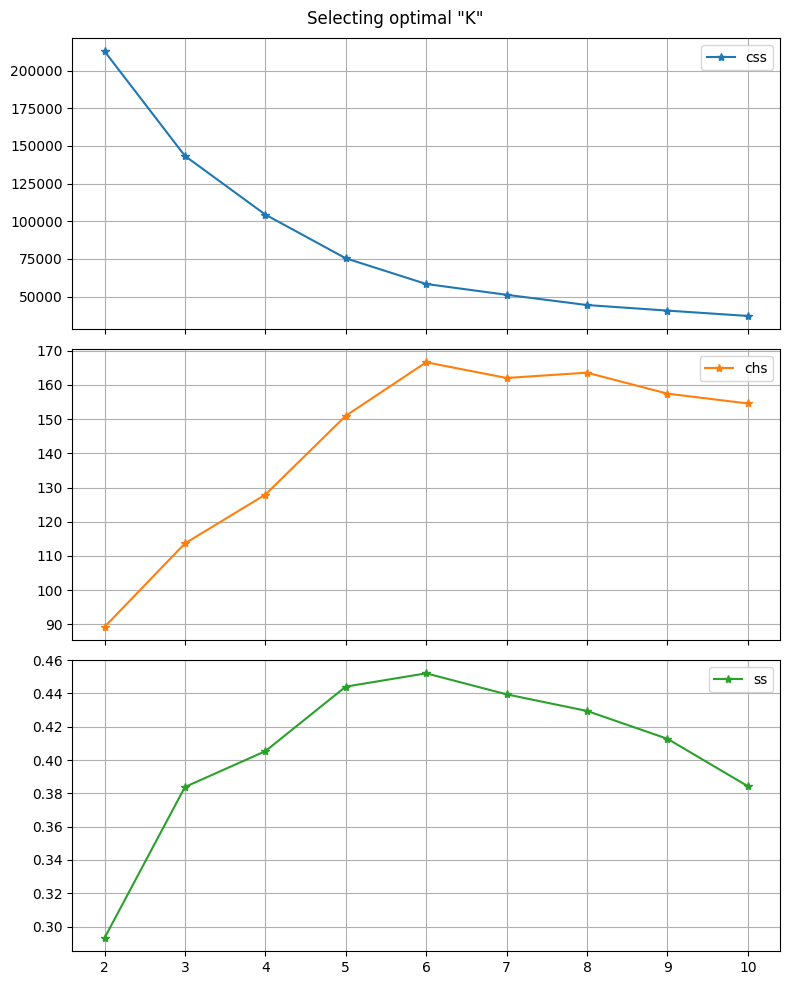

In [ ]:
#plot line plots of all error metrics against K (which is the index)

report.plot(figsize=(8, 10),
               grid=True,
               title=f'Selecting optimal "K"',
               subplots=True,
               marker='*',
               sharex=True)
plt.tight_layout()
plt.show()

SS and CSS suggests 5 as optimal number of clusters, while CHS suggests 6.

Or use yellowbricks to visualize optimal k.

note that Yellowbriccks calculates using CSS.

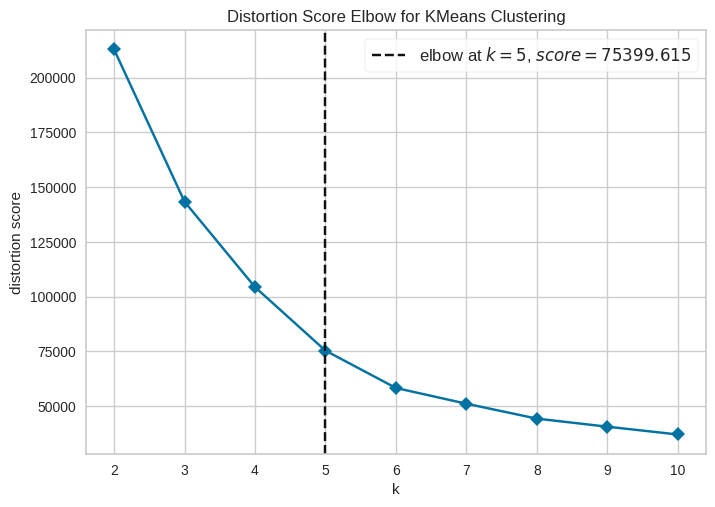

KElbowVisualizer(ax=<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>,
                 estimator=KMeans(max_iter=500, n_clusters=10, random_state=1),
                 k=(2, 11), timings=False)

In [ ]:
from yellowbrick.cluster.elbow import kelbow_visualizer

kelbow_visualizer(KM, Kmeans_customers, k=(2, 11), locate_elbow=True, timings=False)

### Build your model with optimal clusters

In [ ]:
#Initialize model
optimalKM = KMeans(init='k-means++', n_clusters = 5, max_iter = 500, random_state=1)

#Fit your data
optimalKM.fit_predict(Kmeans_customers)

#get cluster labels
clusterlabels = optimalKM.labels_

#Add cluster labels to original data
Kmeans_customers['cluster']= clusterlabels

print(Kmeans_customers.sample(20))

     Gender  Age  Annual Income (k$)  Spending Score (1-100)  cluster
23        1   31                  25                      73        2
170       1   40                  87                      13        1
15        1   22                  20                      79        2
167       0   33                  86                      95        3
199       1   30                 137                      83        3
117       0   49                  65                      59        0
194       0   47                 120                      16        1
134       1   20                  73                       5        1
121       0   38                  67                      40        0
164       1   50                  85                      26        1
66        0   43                  48                      50        0
183       0   29                  98                      88        3
36        0   42                  34                      17        4
97        0   27    

In [ ]:
# Get cluster centroids
centroids = optimalKM.cluster_centers_
print(centroids)

[[ 0.41772152 43.08860759 55.29113924 49.56962025]
 [ 0.52777778 40.66666667 87.75       17.58333333]
 [ 0.39130435 25.52173913 26.30434783 78.56521739]
 [ 0.46153846 32.69230769 86.53846154 82.12820513]
 [ 0.39130435 45.2173913  26.30434783 20.91304348]]


Visualize the segments and their centroids resulting from Partitional (Kmeans) clustering

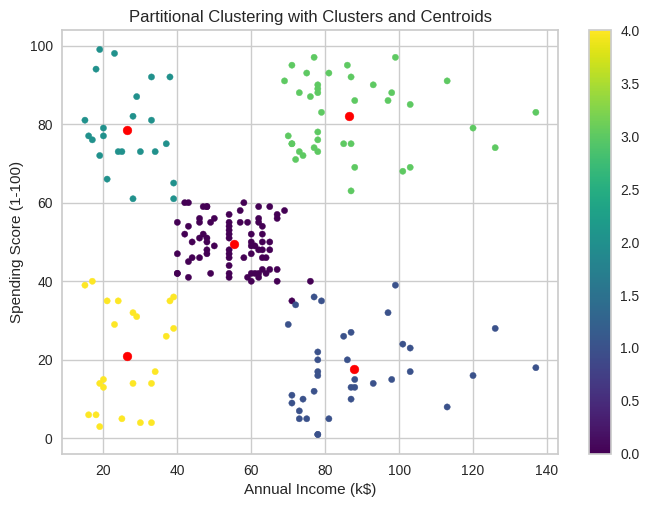

In [ ]:
# Create the figure and axis
fig = plt.figure()
ax = fig.add_subplot(111)

# Scatter plot for the clusters
scatter = ax.scatter(Kmeans_customers['Annual Income (k$)'],
                     Kmeans_customers["Spending Score (1-100)"],
                     s=20, c=Kmeans_customers['cluster'], cmap='viridis')

# Scatter plot for the centroids
centroid_scatter = ax.scatter(centroids[:, 2], centroids[:, 3],
                              s=40, c='red', label='Centroids')

# Set titles and labels
ax.set_title("Partitional Clustering with Clusters and Centroids")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")

# Add colorbar with the same colormap
plt.colorbar(scatter)

# Display the plot
plt.show()

In [ ]:
#see distribution of clusters

Kmeans_customers.groupby(['cluster']).agg([min,max,np.mean])

Gender               Age                Annual Income (k$)       \
           min max      mean min max       mean                min  max   
cluster                                                                   
0            0   1  0.417722  18  70  43.088608                 40   76   
1            0   1  0.527778  19  59  40.666667                 70  137   
2            0   1  0.391304  18  35  25.521739                 15   39   
3            0   1  0.461538  27  40  32.692308                 69  137   
4            0   1  0.391304  19  67  45.217391                 15   39   

                   Spending Score (1-100)                 
              mean                    min max       mean  
cluster                                                   
0        55.291139                     35  60  49.569620  
1        87.750000                      1  39  17.583333  
2        26.304348                     61  99  78.565217  
3        86.538462                     63  97  82.128205  
4        26.304348                      3  40  20.913043

## Association Rules

- For Recommender systems and [Market-Basket Analysis](https://www.geeksforgeeks.org/market-basket-analysis-in-data-mining/).

In [ ]:
#Install dependency
!pip install mlxtend

#Import libraries
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [ ]:
#Transaction data for market basket analysis
transactions = [['Milk', 'Onion', 'Nutmeg','Kidney Beans','Eggs','Yogurt'],
                ['Milk', 'Onion', 'Nutmeg','Kidney Beans','Eggs','Yogurt'],
                ['Milk', 'Apple', 'Kidney Beans','Eggs'],
                ['Milk', 'Unicorn', 'Corn','Kidney Beans','Yogurt'],
                ['Corn', 'Onion', 'Onion','Kidney Beans','Ice cream','Eggs']]

#Initiate One-hot Encoder
te = TransactionEncoder()

#Apply one-hot-encoding on our dataset
te.fit(transactions)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


TransactionEncoder()

In [ ]:
print(te.columns_)

['Apple', 'Corn', 'Eggs', 'Ice cream', 'Kidney Beans', 'Milk', 'Nutmeg', 'Onion', 'Unicorn', 'Yogurt']


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
te_ary=te.transform(transactions)
print(te_ary)

[[False False  True False  True  True  True  True False  True]
 [False False  True False  True  True  True  True False  True]
 [ True False  True False  True  True False False False False]
 [False  True False False  True  True False False  True  True]
 [False  True  True  True  True False False  True False False]]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Creating a new DataFrame from our Numpy array
trans_df = pd.DataFrame(te_ary, columns=te.columns_)
trans_df

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Apple,Corn,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,False,False,True,False,True,True,True,True,False,True
1,False,False,True,False,True,True,True,True,False,True
2,True,False,True,False,True,True,False,False,False,False
3,False,True,False,False,True,True,False,False,True,True
4,False,True,True,True,True,False,False,True,False,False


In [ ]:
apriori(trans_df, min_support=0.6, use_colnames=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets
0,0.8,(Eggs)
1,1.0,(Kidney Beans)
2,0.8,(Milk)
3,0.6,(Onion)
4,0.6,(Yogurt)
5,0.8,"(Eggs, Kidney Beans)"
6,0.6,"(Eggs, Milk)"
7,0.6,"(Onion, Eggs)"
8,0.8,"(Kidney Beans, Milk)"
9,0.6,"(Onion, Kidney Beans)"


In [ ]:
# Frequent itemsets using Apriori
frequent_itemsets = apriori(trans_df, min_support=0.6, use_colnames=True)
print(frequent_itemsets)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


    support                      itemsets
0       0.8                        (Eggs)
1       1.0                (Kidney Beans)
2       0.8                        (Milk)
3       0.6                       (Onion)
4       0.6                      (Yogurt)
5       0.8          (Eggs, Kidney Beans)
6       0.6                  (Eggs, Milk)
7       0.6                 (Onion, Eggs)
8       0.8          (Kidney Beans, Milk)
9       0.6         (Onion, Kidney Beans)
10      0.6        (Yogurt, Kidney Beans)
11      0.6                (Yogurt, Milk)
12      0.6    (Eggs, Kidney Beans, Milk)
13      0.6   (Onion, Eggs, Kidney Beans)
14      0.6  (Yogurt, Kidney Beans, Milk)


In [ ]:
# Generate association rules
confidence_rules = association_rules(frequent_itemsets, metric="confidence",
                          min_threshold=0.7)
confidence_rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Eggs),(Kidney Beans),0.8,1.0,0.8,1.00,1.0000,0.00,inf,0.00
1,(Kidney Beans),(Eggs),1.0,0.8,0.8,0.80,1.0000,0.00,1.0,0.00
2,(Eggs),(Milk),0.8,0.8,0.6,0.75,0.9375,-0.04,0.8,-0.25
3,(Milk),(Eggs),0.8,0.8,0.6,0.75,0.9375,-0.04,0.8,-0.25
4,(Onion),(Eggs),0.6,0.8,0.6,1.00,1.2500,0.12,inf,0.50
5,(Eggs),(Onion),0.8,0.6,0.6,0.75,1.2500,0.12,1.6,1.00
6,(Kidney Beans),(Milk),1.0,0.8,0.8,0.80,1.0000,0.00,1.0,0.00
7,(Milk),(Kidney Beans),0.8,1.0,0.8,1.00,1.0000,0.00,inf,0.00
8,(Onion),(Kidney Beans),0.6,1.0,0.6,1.00,1.0000,0.00,inf,0.00
9,(Yogurt),(Kidney Beans),0.6,1.0,0.6,1.00,1.0000,0.00,inf,0.00


In [ ]:
# Generate association rules
lift_rules = association_rules(frequent_itemsets, metric="lift",
                          min_threshold=1.20)
lift_rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Onion),(Eggs),0.6,0.8,0.6,1.00,1.25,0.12,inf,0.5
1,(Eggs),(Onion),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1.0
2,(Yogurt),(Milk),0.6,0.8,0.6,1.00,1.25,0.12,inf,0.5
3,(Milk),(Yogurt),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1.0
4,"(Onion, Kidney Beans)",(Eggs),0.6,0.8,0.6,1.00,1.25,0.12,inf,0.5
5,"(Eggs, Kidney Beans)",(Onion),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1.0
6,(Onion),"(Eggs, Kidney Beans)",0.6,0.8,0.6,1.00,1.25,0.12,inf,0.5
7,(Eggs),"(Onion, Kidney Beans)",0.8,0.6,0.6,0.75,1.25,0.12,1.6,1.0
8,"(Yogurt, Kidney Beans)",(Milk),0.6,0.8,0.6,1.00,1.25,0.12,inf,0.5
9,"(Kidney Beans, Milk)",(Yogurt),0.8,0.6,0.6,0.75,1.25,0.12,1.6,1.0


In [ ]:
! gcloud --version

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Google Cloud SDK 487.0.0


In [ ]:
market_df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTGtwwhhGedZe2QrvNhJXjSoyG50IXTNNS9QVrxr9uelZvagZayhr7XIGVSQBk7hC8v8xDl0vm2UJFr/pub?gid=1179270371&single=true&output=csv', header=None)
market_df

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import math
market_list = []
for index,row in market_df.iterrows():
  basket = [item for item in row.tolist() if isinstance(item,str)]
  market_list.append(basket)

print(market_list)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil'], ['burgers', 'meatballs', 'eggs'], ['chutney'], ['turkey', 'avocado'], ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'], ['low fat yogurt'], ['whole wheat pasta', 'french fries'], ['soup', 'light cream', 'shallot'], ['frozen vegetables', 'spaghetti', 'green tea'], ['french fries'], ['eggs', 'pet food'], ['cookies'], ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil'], ['spaghetti', 'champagne', 'cookies'], ['mineral water', 'salmon'], ['mineral water'], ['shrimp', 'chocolate', 'chicken', 'honey', 'oil', 'cooking oil', 'low fat yogurt'], ['turkey', 'eggs'], ['turkey', 'fresh tuna', 'tomatoes', 'spaghetti', 'mineral water', 'black tea', 'salmon', 'eggs', 'chicken', 'extra d

In [ ]:
import csv

lists = []

with open('/content/Market_Basket_Optimisation.csv', mode='r') as file:
  # Create a CSV reader object
  csv_reader = csv.reader(file)

  # Iterate over each row in the CSV
  for row in csv_reader:
    # Append the row to the list
    lists.append(row)

print(lists)

[['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil'], ['burgers', 'meatballs', 'eggs', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['chutney', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['turkey', 'avocado', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['low fat yogurt', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['whole wheat pasta', 'french fries', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], ['soup', 'light cream', 'shallot', '', '', '', '', '', '', '', '', '', '', '', '', '',

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
trans_encode = TransactionEncoder()
market_ar = trans_encode.fit_transform(market_list)
market_trans_df = pd.DataFrame(market_ar, columns=trans_encode.columns_)
market_trans_df

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,True,True,False,True,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
frequent_items = apriori(market_trans_df, min_support=0.01, use_colnames=True)

frequent_items

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets
0,0.020397,(almonds)
1,0.033329,(avocado)
2,0.010799,(barbecue sauce)
3,0.014265,(black tea)
4,0.011465,(body spray)
...,...,...
252,0.011065,"(mineral water, milk, ground beef)"
253,0.017064,"(mineral water, spaghetti, ground beef)"
254,0.015731,"(milk, spaghetti, mineral water)"
255,0.010265,"(spaghetti, mineral water, olive oil)"


In [ ]:
good_pairs = association_rules(frequent_items, metric='lift',min_threshold=1.5)
good_pairs

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(burgers),(cake),0.087188,0.081056,0.011465,0.131498,1.622319,0.004398,1.058080,0.420238
1,(cake),(burgers),0.081056,0.087188,0.011465,0.141447,1.622319,0.004398,1.063198,0.417434
2,(burgers),(eggs),0.087188,0.179709,0.028796,0.330275,1.837830,0.013128,1.224818,0.499424
3,(eggs),(burgers),0.179709,0.087188,0.028796,0.160237,1.837830,0.013128,1.086988,0.555754
4,(burgers),(green tea),0.087188,0.132116,0.017464,0.200306,1.516139,0.005945,1.085270,0.372947
...,...,...,...,...,...,...,...,...,...,...
209,"(pancakes, mineral water)",(spaghetti),0.033729,0.174110,0.011465,0.339921,1.952333,0.005593,1.251198,0.504819
210,"(spaghetti, pancakes)",(mineral water),0.025197,0.238368,0.011465,0.455026,1.908923,0.005459,1.397557,0.488452
211,(mineral water),"(spaghetti, pancakes)",0.238368,0.025197,0.011465,0.048098,1.908923,0.005459,1.024059,0.625163
212,(spaghetti),"(pancakes, mineral water)",0.174110,0.033729,0.011465,0.065850,1.952333,0.005593,1.034385,0.590626


In [ ]:
good_pairs.columns

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Index(['antecedents', 'consequents', 'antecedent support',
       'consequent support', 'support', 'confidence', 'lift', 'leverage',
       'conviction', 'zhangs_metric'],
      dtype='object')

In [ ]:
market_data = good_pairs.drop(['confidence','leverage','conviction',
                               'zhangs_metric'], axis=1) #remove some columns

market_data = market_data.sort_values('lift', ascending=False) #sort by lift in descending order

#round up metrics to 2dp
cols_to_round = ['antecedent support',	'consequent support',	'support',	'lift']
market_data[cols_to_round] = market_data[cols_to_round].astype(float).round(2)

market_data.reset_index(drop=True, inplace=True)
market_data.to_csv('Market basket data.csv')

market_data.head(15)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,lift
61,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,3.291994
60,(ground beef),(herb & pepper),0.098254,0.049460,0.015998,3.291994
195,(ground beef),"(spaghetti, mineral water)",0.098254,0.059725,0.017064,2.907928
190,"(spaghetti, mineral water)",(ground beef),0.059725,0.098254,0.017064,2.907928
202,"(spaghetti, mineral water)",(olive oil),0.059725,0.065858,0.010265,2.609786
207,(olive oil),"(spaghetti, mineral water)",0.065858,0.059725,0.010265,2.609786
54,(frozen vegetables),(tomatoes),0.095321,0.068391,0.016131,2.474464
55,(tomatoes),(frozen vegetables),0.068391,0.095321,0.016131,2.474464
50,(shrimp),(frozen vegetables),0.071457,0.095321,0.016664,2.446574
51,(frozen vegetables),(shrimp),0.095321,0.071457,0.016664,2.446574


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


The dataset contains the following columns:

1. **antecedents**: The items in the antecedent of the association rule (e.g., "herb & pepper").
2. **consequents**: The items in the consequent of the association rule (e.g., "ground beef").
3. **antecedent support**: The frequency of occurrence of the antecedent in the dataset.
4. **consequent support**: The frequency of occurrence of the consequent in the dataset.
5. **support**: The frequency of occurrence of both the antecedent and consequent together.
6. **lift**: The lift value of the rule, which indicates the strength of the association.

### Business Insights:

Based on the results of the Apriori analysis, here are some potential insights for the supermarket owners:

1. **Product Bundling**:
   - Items with a high lift value are often bought together more frequently than would be expected by chance. These products could be bundled together as a package deal. For example, if "herb & pepper" and "ground beef" have a high lift, the supermarket could offer a discount on these items when purchased together.
   
2. **Cross-Promotions**:
   - Items with strong associations can be promoted together. For example, if "spaghetti" and "mineral water" often appear together, the supermarket could run promotions like "Buy spaghetti, get a discount on mineral water".
   
3. **Store Layout Optimization**:
   - The supermarket could consider placing items that are frequently bought together close to each other in the store. For example, if "ground beef" and "herb & pepper" are often bought together, placing them in adjacent aisles could increase sales.

4. **Inventory Management**:
   - Items with strong associations should be kept in stock simultaneously. If one item goes out of stock, it could potentially decrease the sale of the associated item(s). Ensuring that associated items are always available could maximize sales.

5. **Personalized Recommendations**:
   - For online supermarkets or loyalty program users, the store could use this data to offer personalized recommendations. If a customer buys "spaghetti", they could be recommended "mineral water" based on the association rule.

6. **New Product Placement**:
   - If there are new products that have similar characteristics to those in the association rules, placing them near the associated items might increase their sales. For example, if a new type of pasta is introduced, placing it near "spaghetti" might encourage customers to try it.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


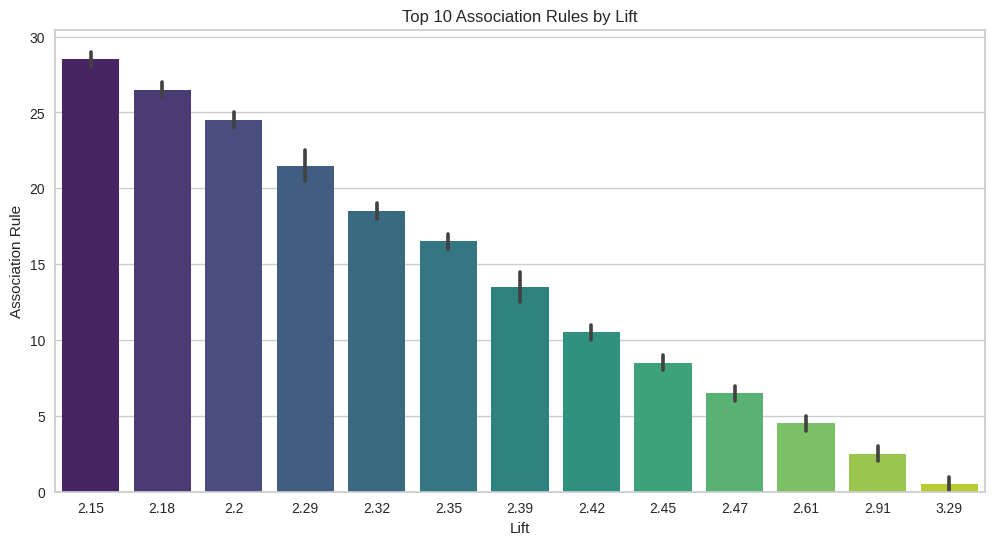

In [ ]:
#Bar Plot for Top Lift Values

import seaborn as sns

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='lift', y=market_data.head(30).index, data=market_data.head(30), palette="viridis")
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.show()

In [ ]:
market_data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,lift
0,frozenset({'herb & pepper'}),frozenset({'ground beef'}),0.05,0.10,0.02,3.29
1,frozenset({'ground beef'}),frozenset({'herb & pepper'}),0.10,0.05,0.02,3.29
2,frozenset({'ground beef'}),"frozenset({'spaghetti', 'mineral water'})",0.10,0.06,0.02,2.91
3,"frozenset({'spaghetti', 'mineral water'})",frozenset({'ground beef'}),0.06,0.10,0.02,2.91
4,"frozenset({'spaghetti', 'mineral water'})",frozenset({'olive oil'}),0.06,0.07,0.01,2.61


In [ ]:
text_cols = ['antecedents','consequents']
market_data[text_cols]= market_data[text_cols].astype(str)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
for col in text_cols:
  market_data[col]=market_data[col].str.replace('()','')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


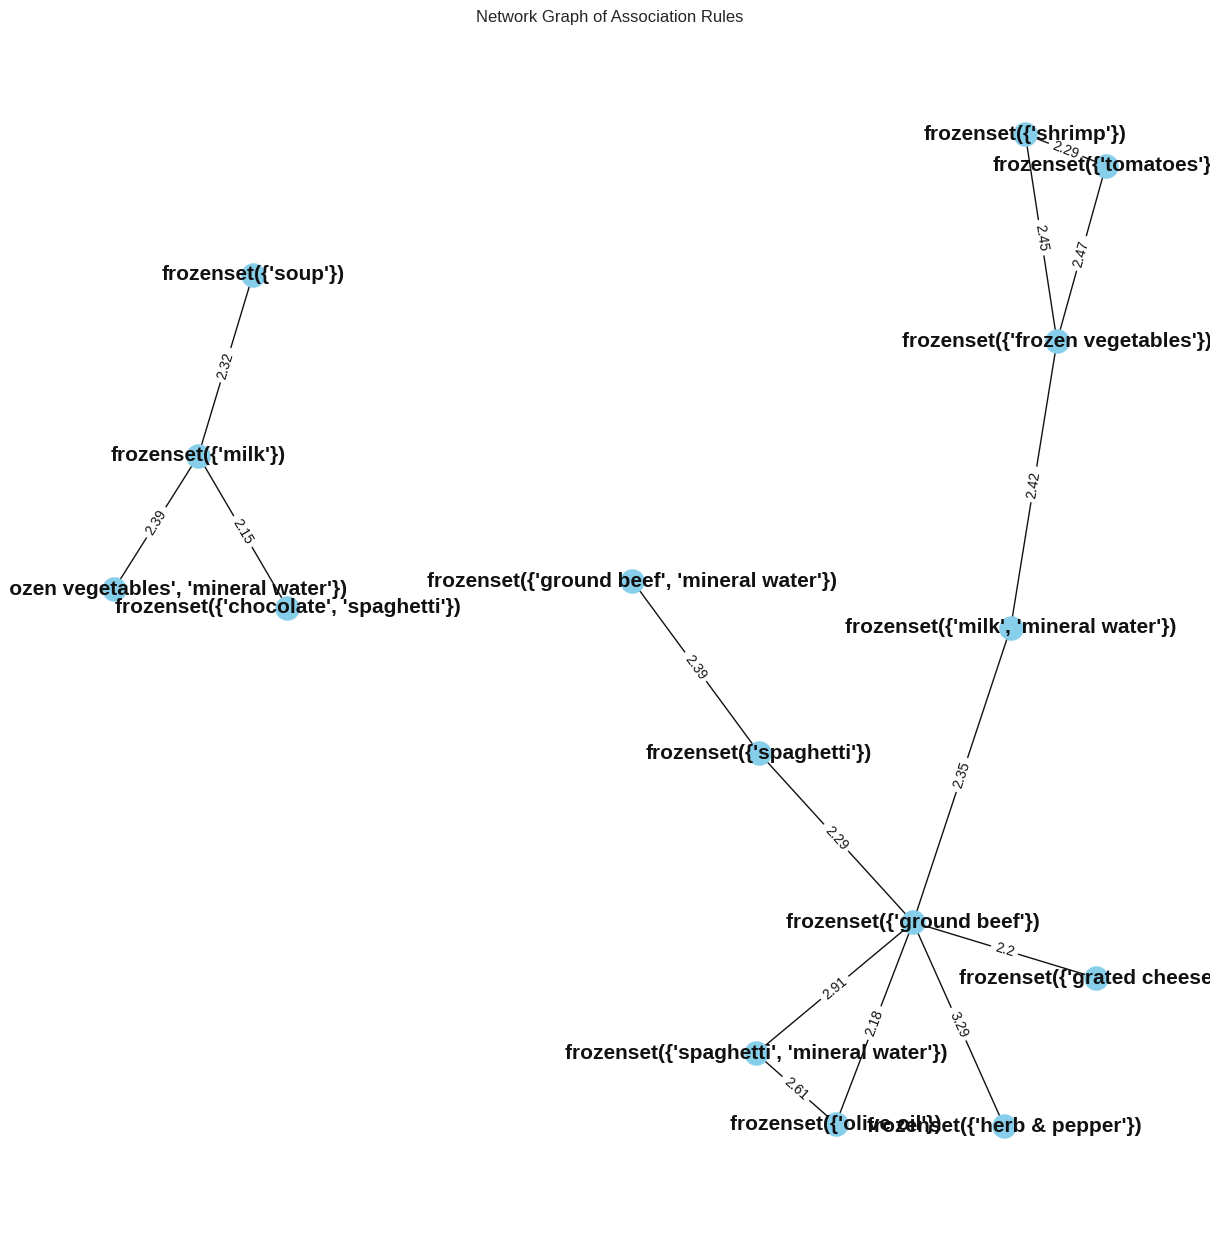

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(market_data.head(30), 'antecedents', 'consequents', ['lift'])

pos = nx.spring_layout(G, k=0.5)
plt.figure(figsize=(12, 12))

# Draw the network
nx.draw(G, pos, with_labels=True, node_size=300, node_color="skyblue", font_size=15, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'lift'))

plt.title('Network Graph of Association Rules')
plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


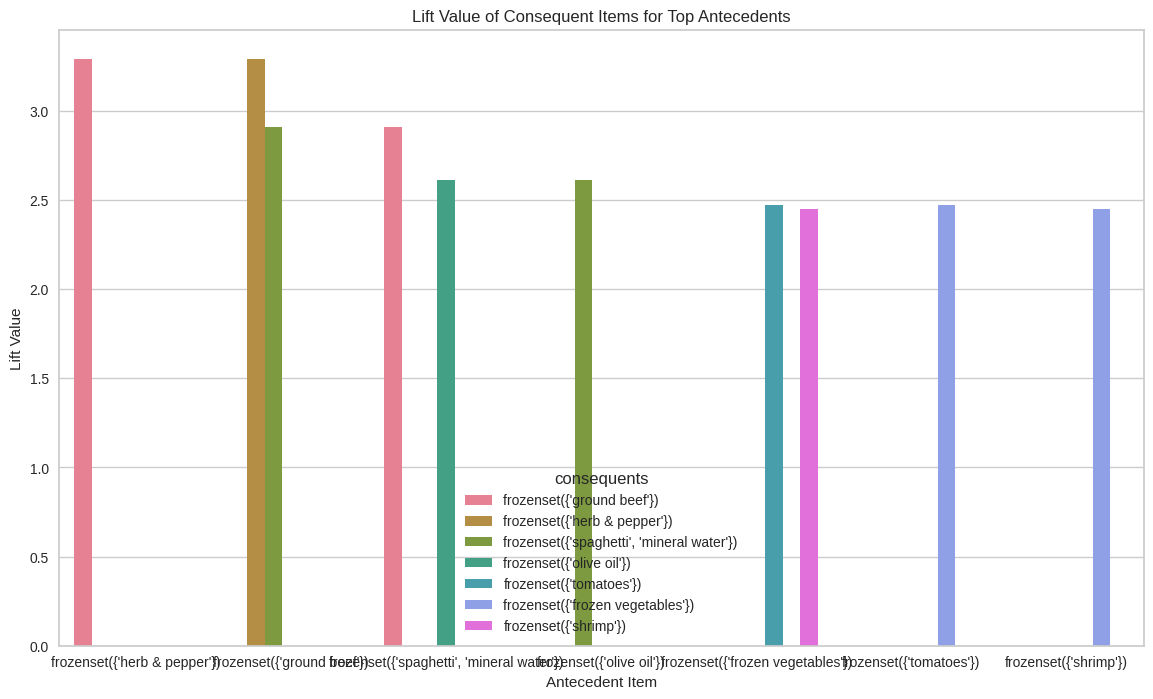

In [ ]:
# Clustered Bar Chart for Product Bundling Opportunities

# clustered bar chart
'''top_items = market_data['antecedents'].value_counts().head(5).index.tolist()
filtered_df = market_data[market_data['antecedents'].isin(top_items)]'''

plt.figure(figsize=(14, 8))
sns.barplot(x='antecedents', y='lift', hue='consequents', data=market_data.head(10))
plt.title('Lift Value of Consequent Items for Top Antecedents')
plt.xlabel('Antecedent Item')
plt.ylabel('Lift Value')
plt.legend(title='Consequent Item')
plt.show()


c

# NEURAL NETWORKS

Using Keras